# Task 2: Exploratory Data Analysis (EDA) - Titanic Dataset
## Objective:
Understand the dataset using descriptive statistics, univariate, bivariate, and multivariate visualizations. Identify patterns, trends, correlations, and anomalies (outliers) to derive key feature-level inferences.

### Tools Used:
- **Pandas**: Data manipulation, statistical aggregation, grouping.
- **Matplotlib & Seaborn**: Static publication-grade visualizations (histograms, boxplots, heatmaps, pairplots).
- **Plotly**: Interactive 3D and hierarchical visualizations.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Set aesthetic visual parameters
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 11, 'figure.titlesize': 16})

# Load Dataset
df = pd.read_csv("titanic_eda_enhanced.csv")
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (891, 16)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone,AgeGroup,FareGroup
0,1,1,2,"Passenger, Person 1",female,60.980969,0,1,340001,21.103981,NaN,S,2,0,Senior,Medium-High
1,2,0,3,"Passenger, Person 2",female,20.917134,1,1,340002,7.291551,A10,S,3,0,Adult,Low
2,3,0,3,"Passenger, Person 3",male,40.460383,0,0,340003,10.841112,NaN,S,1,1,Middle-Aged,Medium-Low
3,4,1,3,"Passenger, Person 4",female,NaN,0,0,340004,11.923463,NaN,S,1,1,NaN,Medium-Low
4,5,0,1,"Passenger, Person 5",male,48.575249,0,0,PC 17005,117.695124,NaN,S,1,1,Middle-Aged,High


## 1. Summary Statistics
Generating comprehensive descriptive statistics for numeric and categorical features including mean, median, standard deviation, min, max, skewness, kurtosis, IQR, and missing value counts.


In [2]:
# Summary statistics for numerical variables
num_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize', 'Pclass', 'Survived']
num_summary = df[num_cols].describe().T
num_summary['median'] = df[num_cols].median()
num_summary['skewness'] = df[num_cols].skew()
num_summary['kurtosis'] = df[num_cols].kurt()
num_summary['IQR'] = num_summary['75%'] - num_summary['25%']
num_summary['missing_count'] = df[num_cols].isnull().sum()
num_summary['missing_pct'] = (df[num_cols].isnull().sum() / len(df)) * 100

num_summary.round(3)


,count,mean,std,min,25%,50%,75%,max,median,skewness,kurtosis,IQR,missing_count,missing_pct
Age,713.0,30.462,14.079,0.42,20.887,30.003,39.652,76.000,30.003,0.131,-0.117,18.765,178,19.978
Fare,891.0,40.241,64.287,0.00,8.611,18.865,35.488,505.227,18.865,3.429,15.027,26.877,0,0.000
SibSp,891.0,0.489,1.135,0.00,0.000,0.000,1.000,8.000,0.000,3.852,18.505,1.000,0,0.000
Parch,891.0,0.411,0.888,0.00,0.000,0.000,0.000,6.000,0.000,2.911,10.682,0.000,0,0.000
FamilySize,891.0,1.900,1.415,1.00,1.000,1.000,2.000,11.000,1.000,2.579,9.304,1.000,0,0.000
Pclass,891.0,2.287,0.848,1.00,1.000,3.000,3.000,3.000,3.000,-0.585,-1.360,2.000,0,0.000
Survived,891.0,0.421,0.494,0.00,0.000,0.000,1.000,1.000,0.000,0.321,-1.901,1.000,0,0.000


## 2. Univariate Visualizations: Histograms & Boxplots
Histograms with KDE curves and boxplots to examine distribution shape, central tendency, variance, and detect anomalies/outliers.


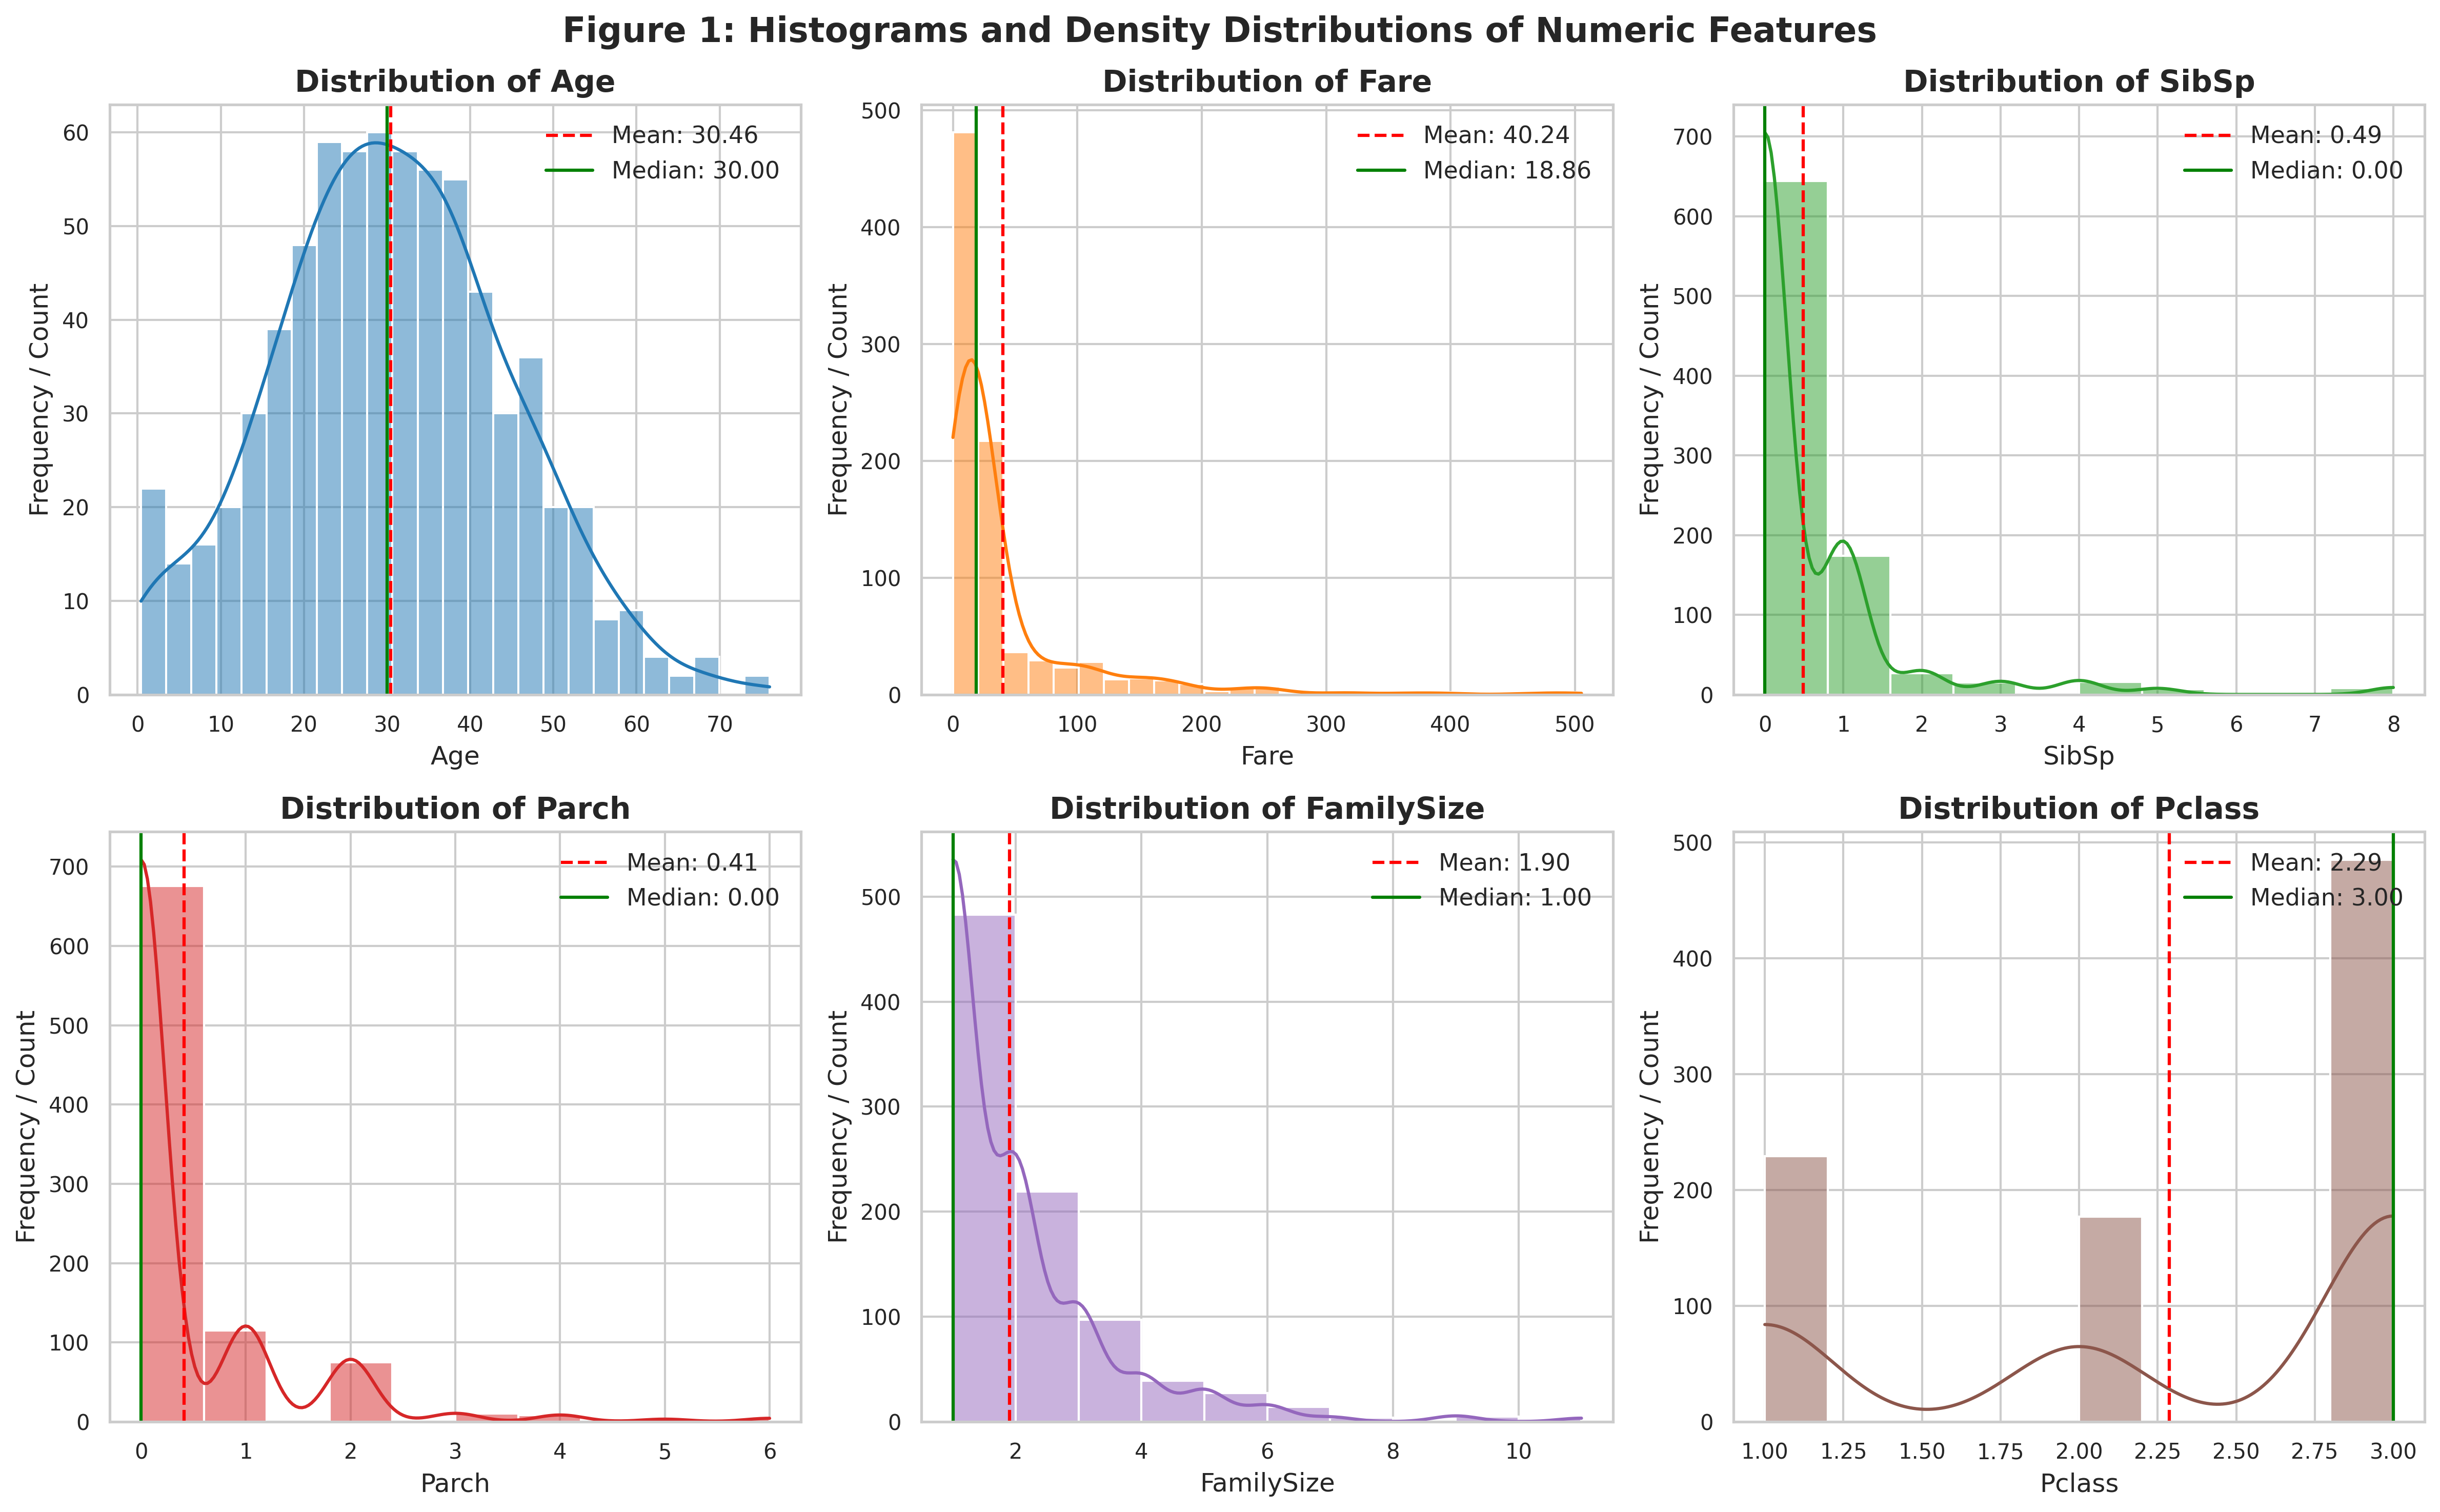

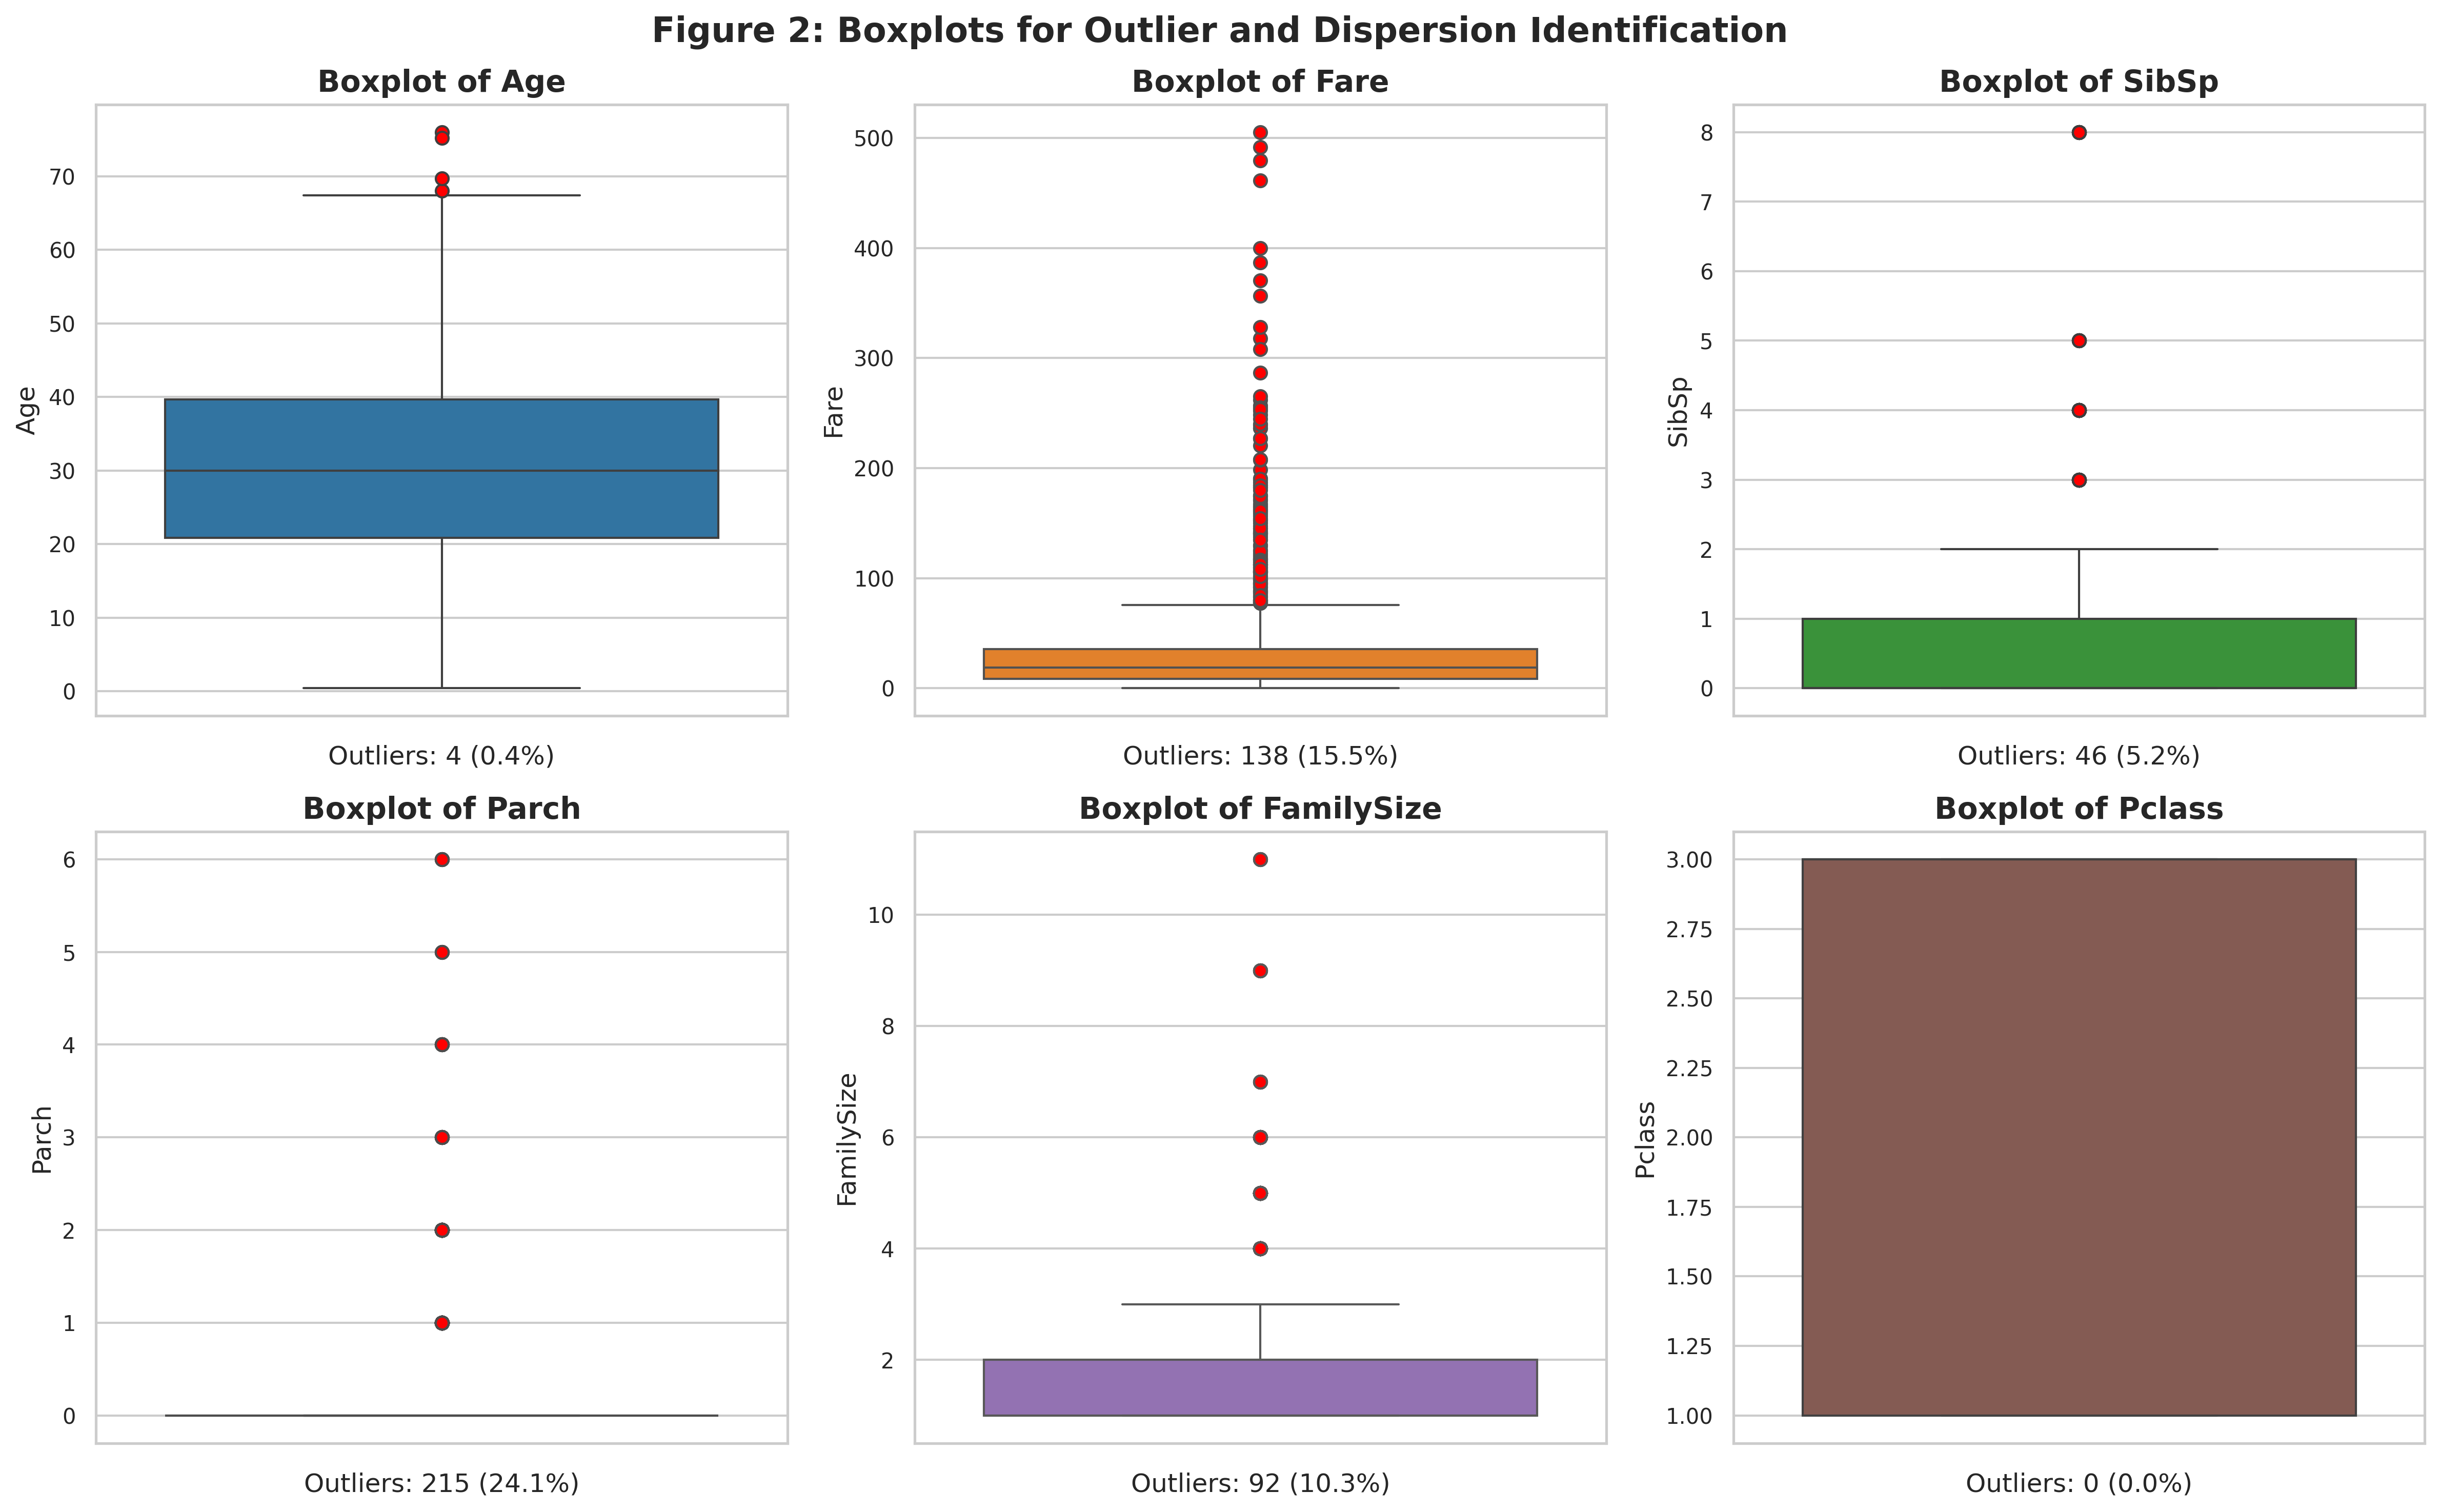

In [3]:
# Display generated static figures inline
from IPython.display import Image, display

display(Image(filename="plots/01_summary_histograms.png"))
display(Image(filename="plots/02_numeric_boxplots.png"))


## 3. Bivariate & Stratified Analysis
Analyzing relationships between passenger demographics (Sex, Pclass, Embarked, FamilySize) and survival rates.


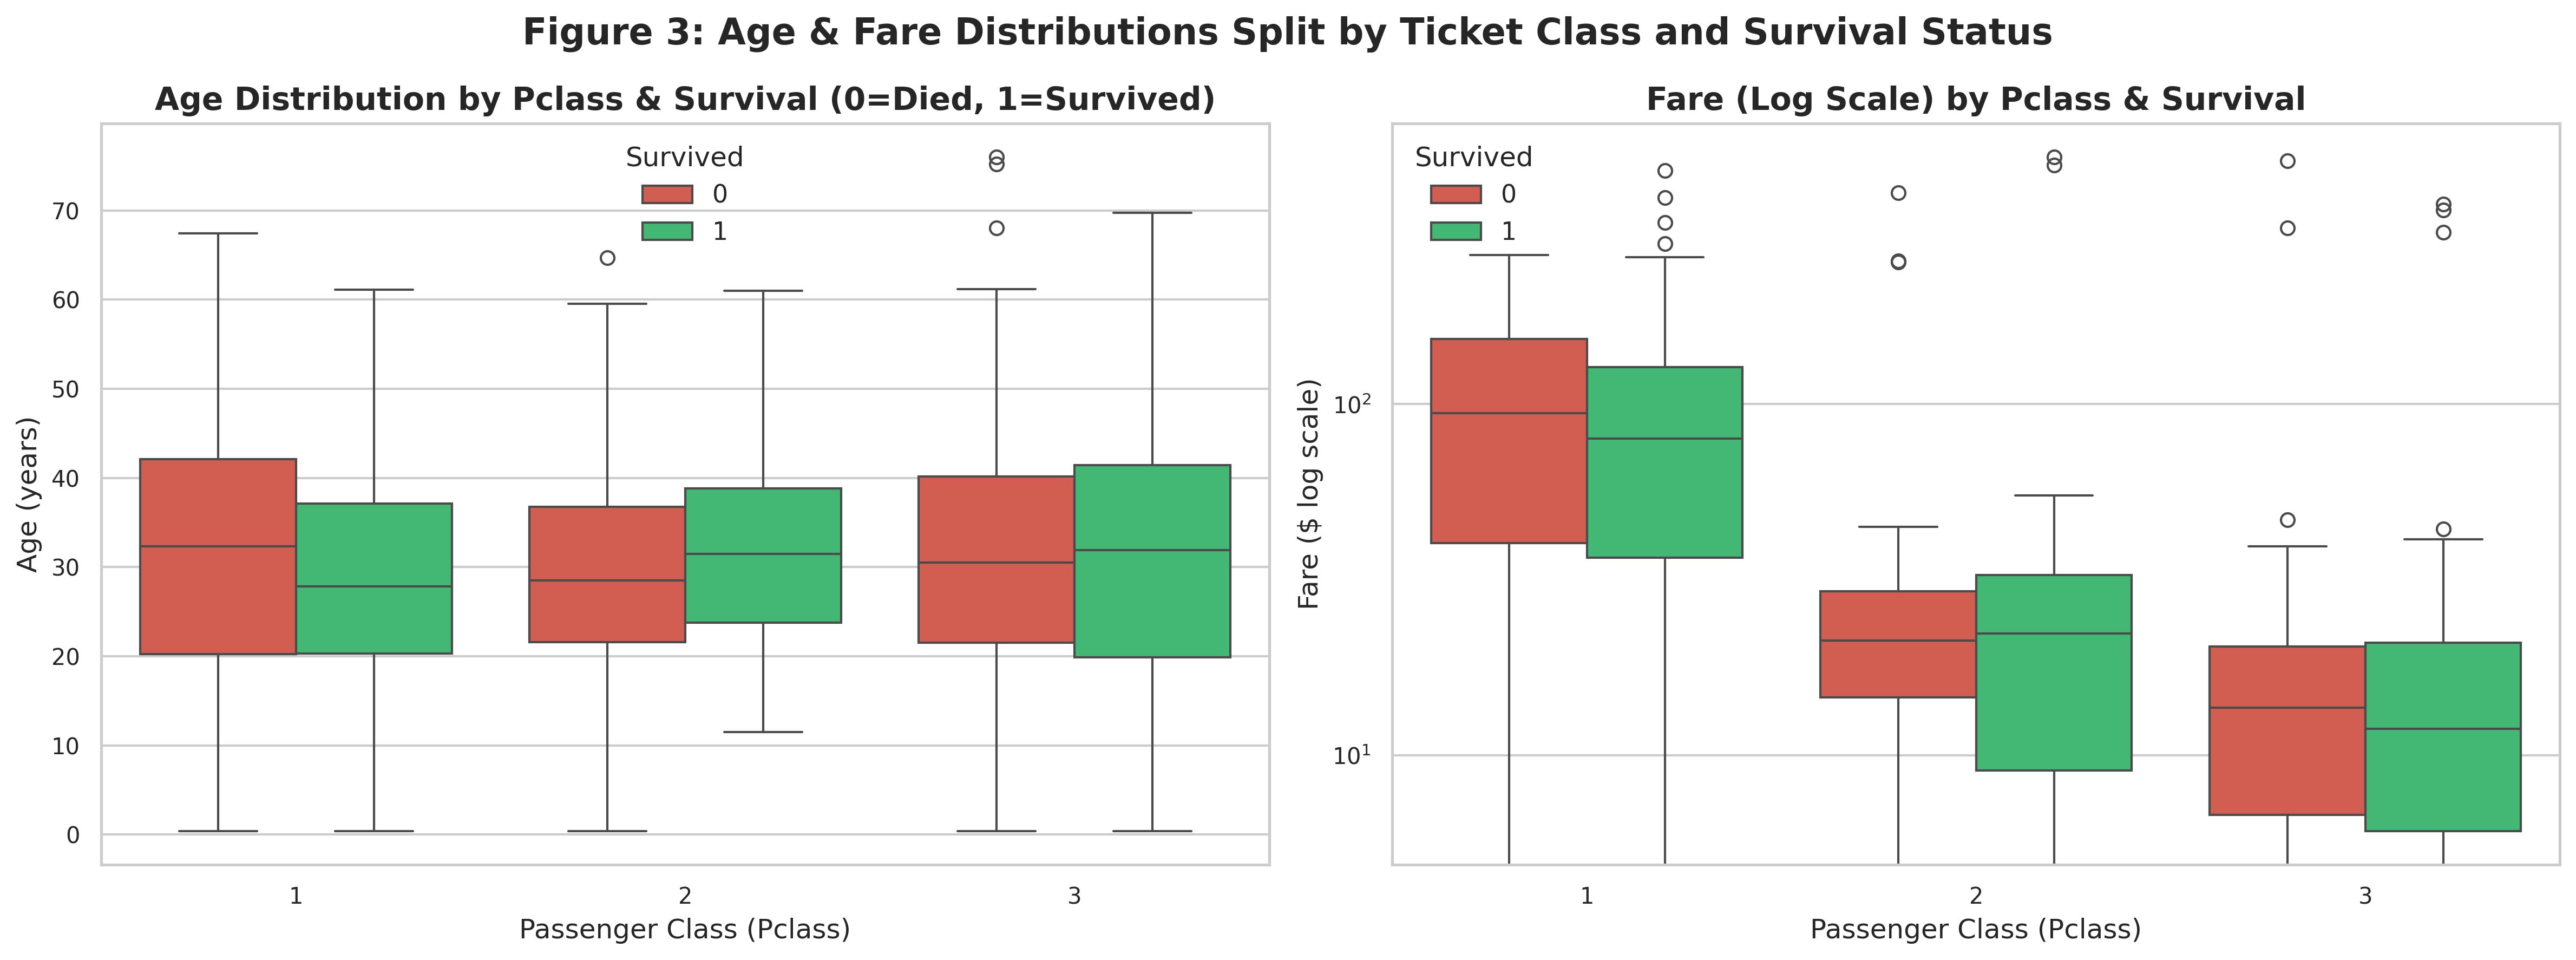

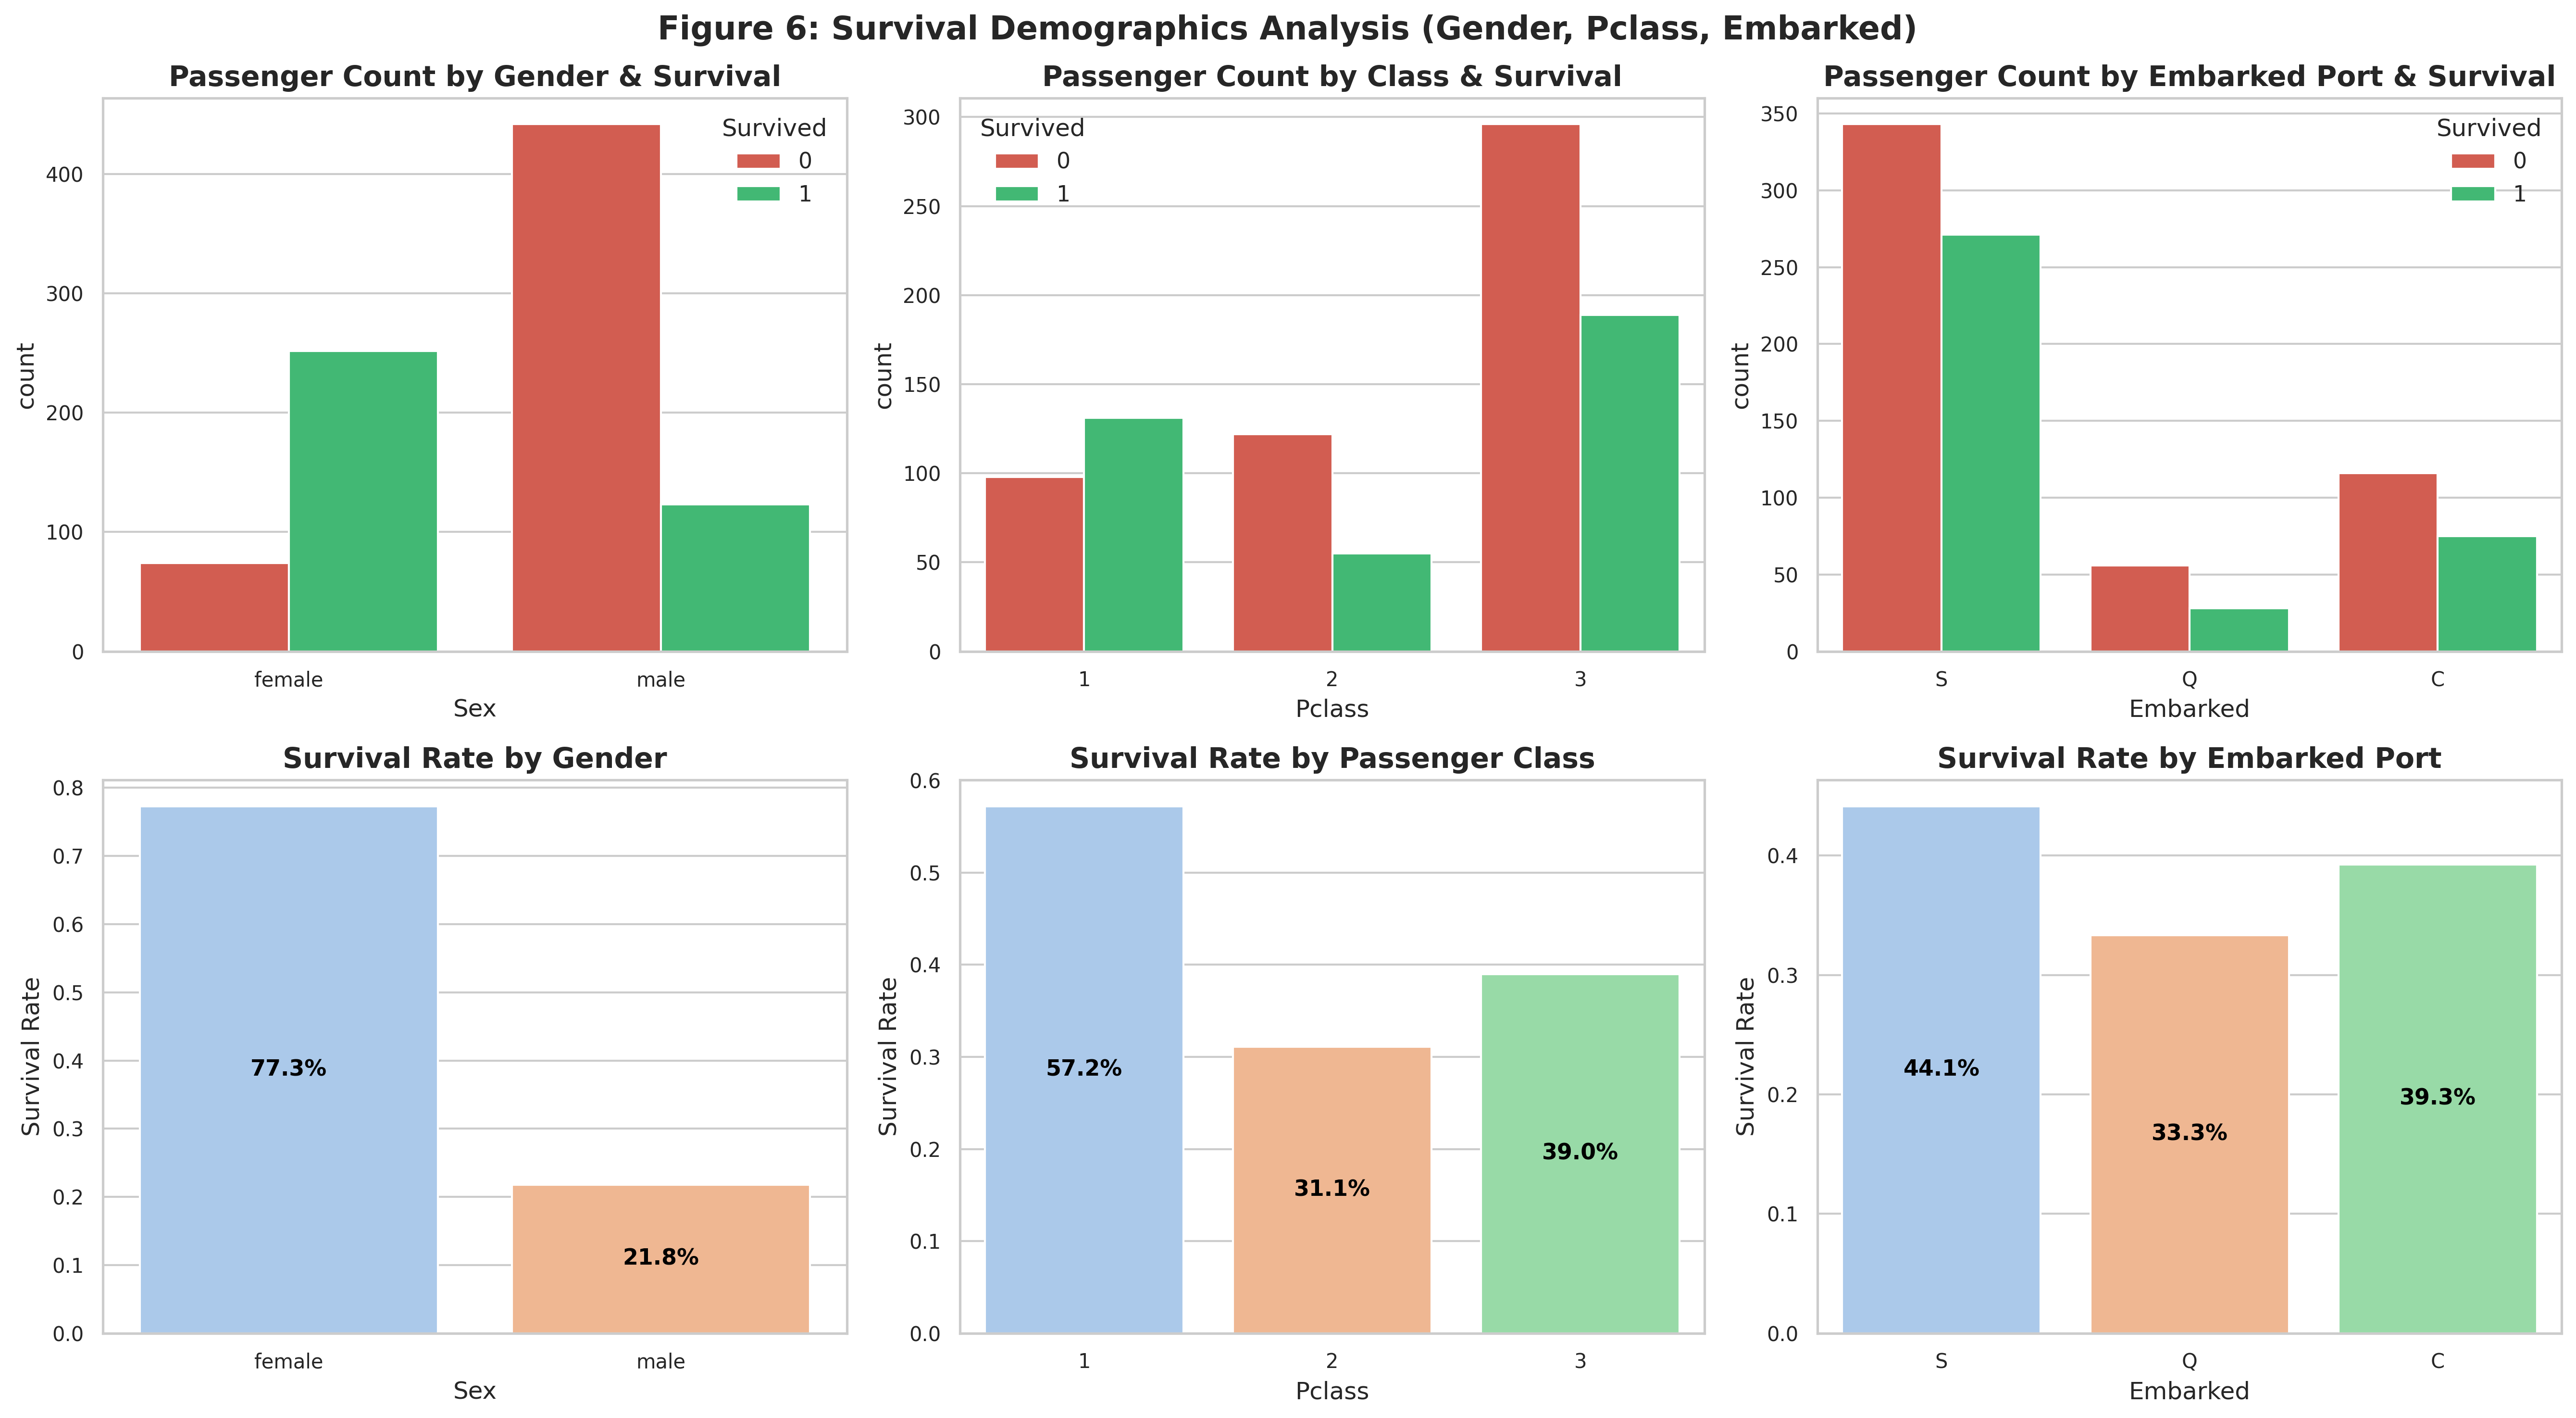

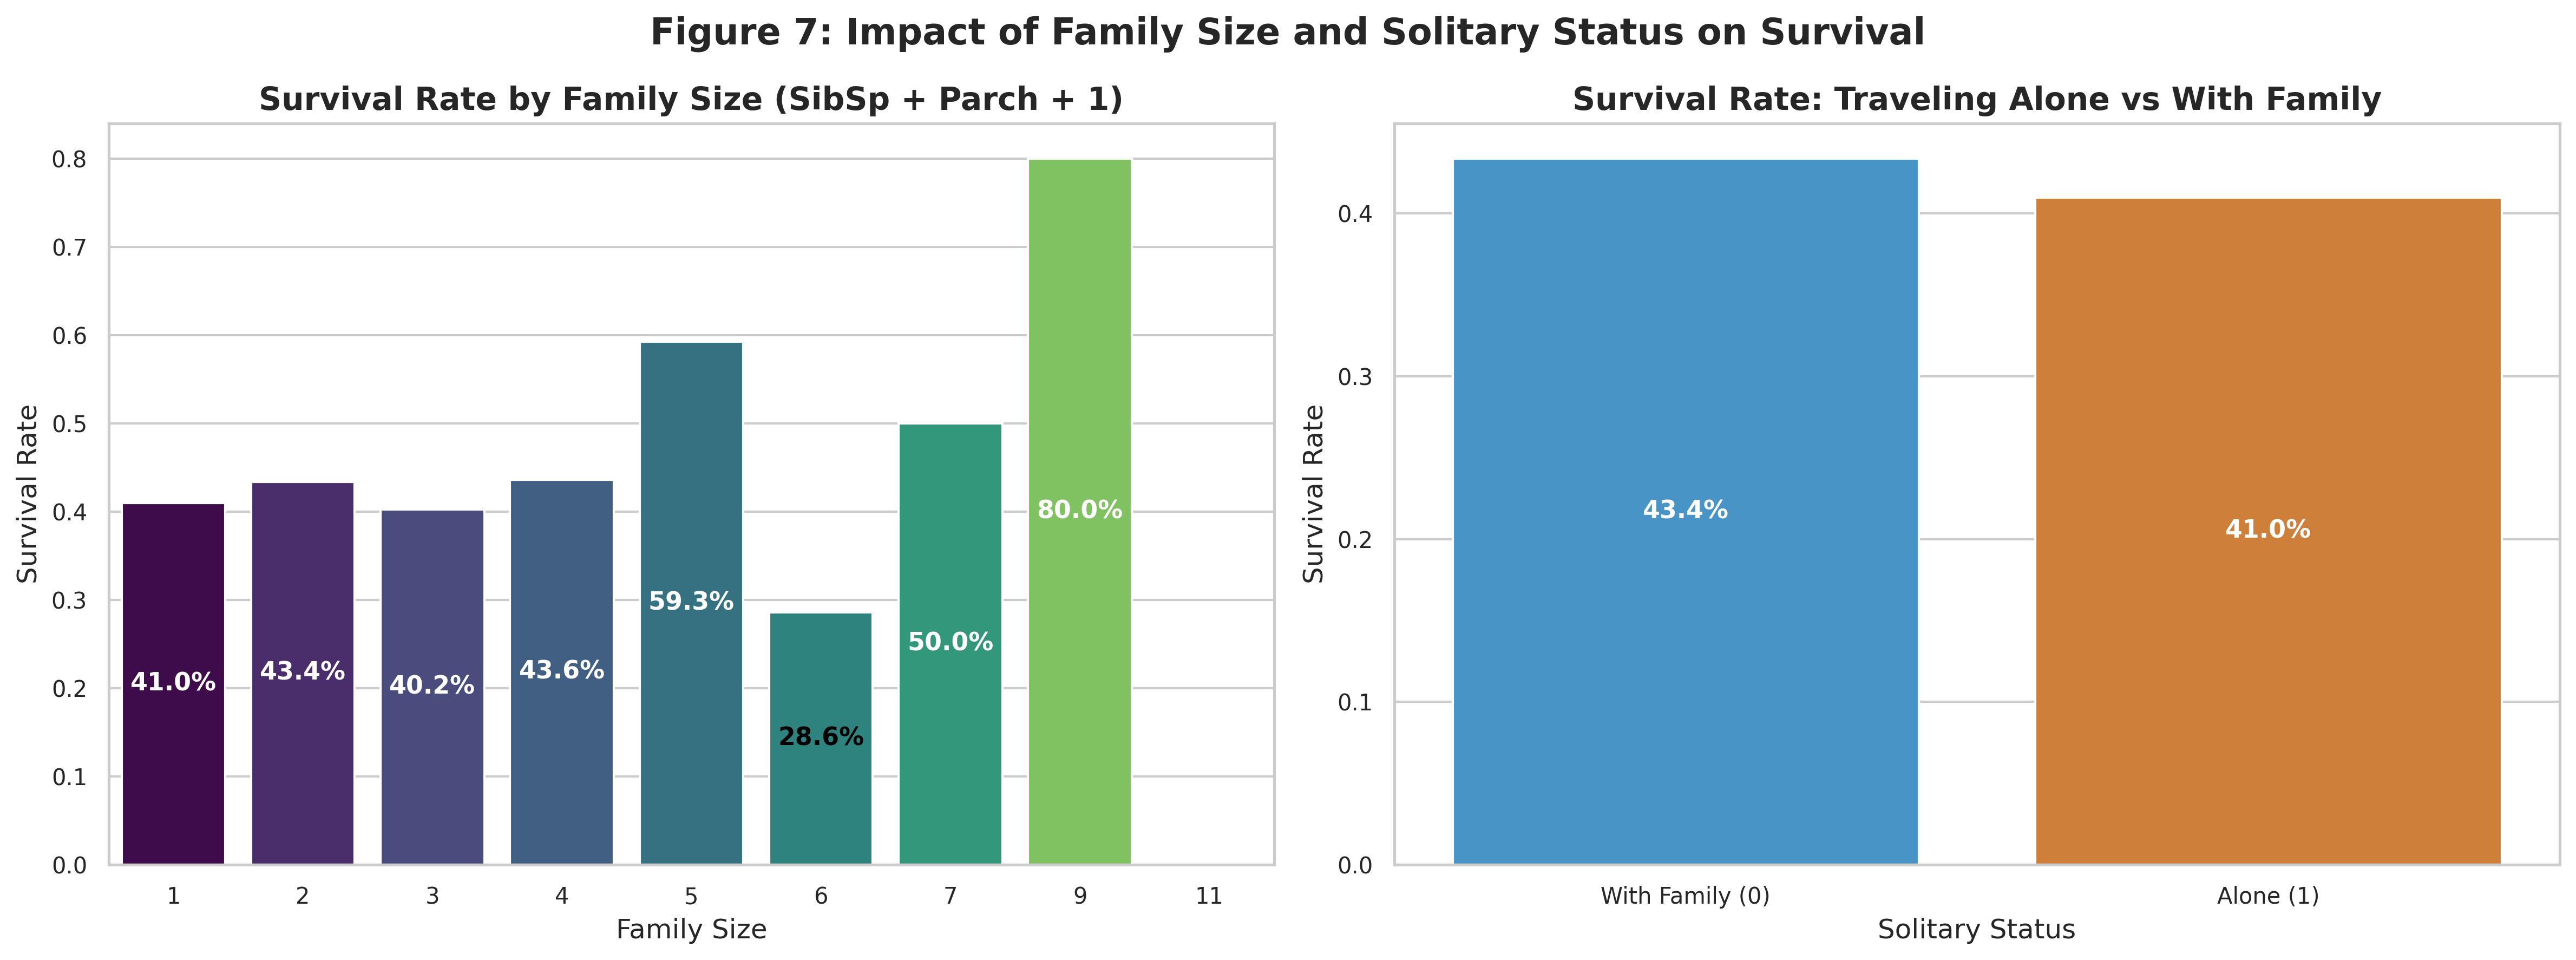

In [4]:
display(Image(filename="plots/03_boxplots_by_survival_class.png"))
display(Image(filename="plots/06_survival_demographics.png"))
display(Image(filename="plots/07_family_and_alone_analysis.png"))


## 4. Feature Relationships & Pairplots
Correlation matrix heatmap and pairplot across numeric attributes colored by Survival status.


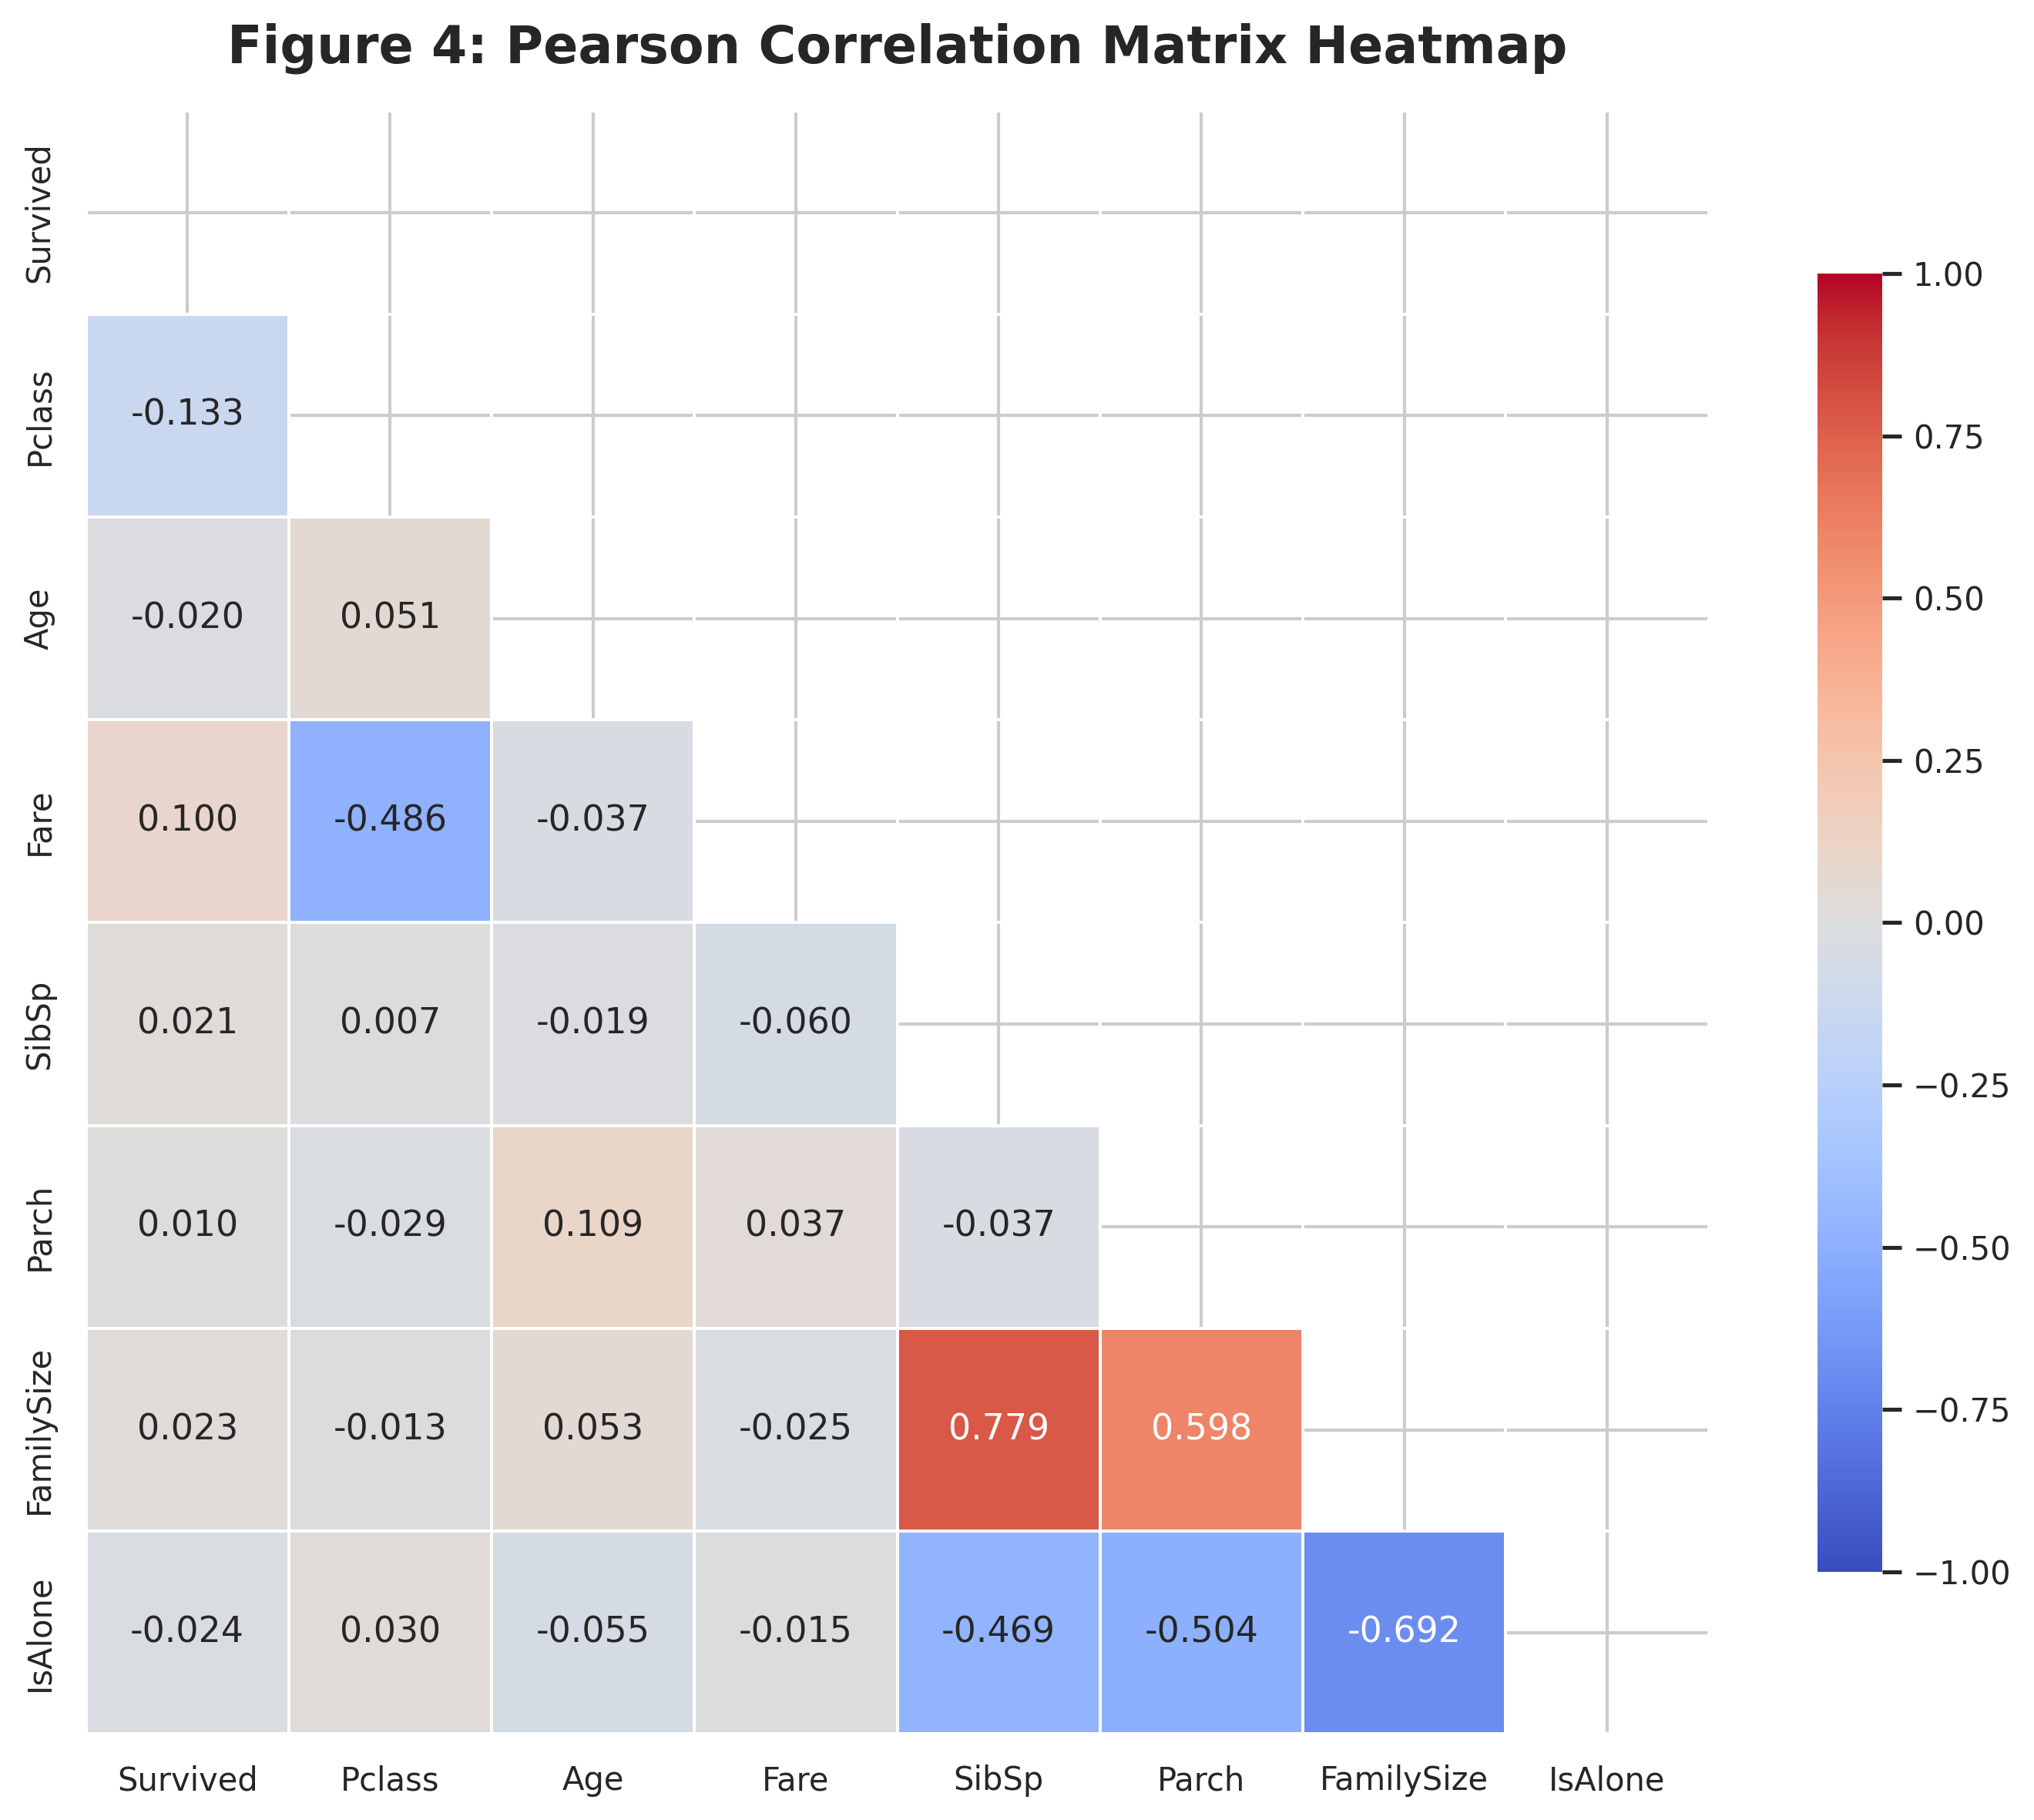

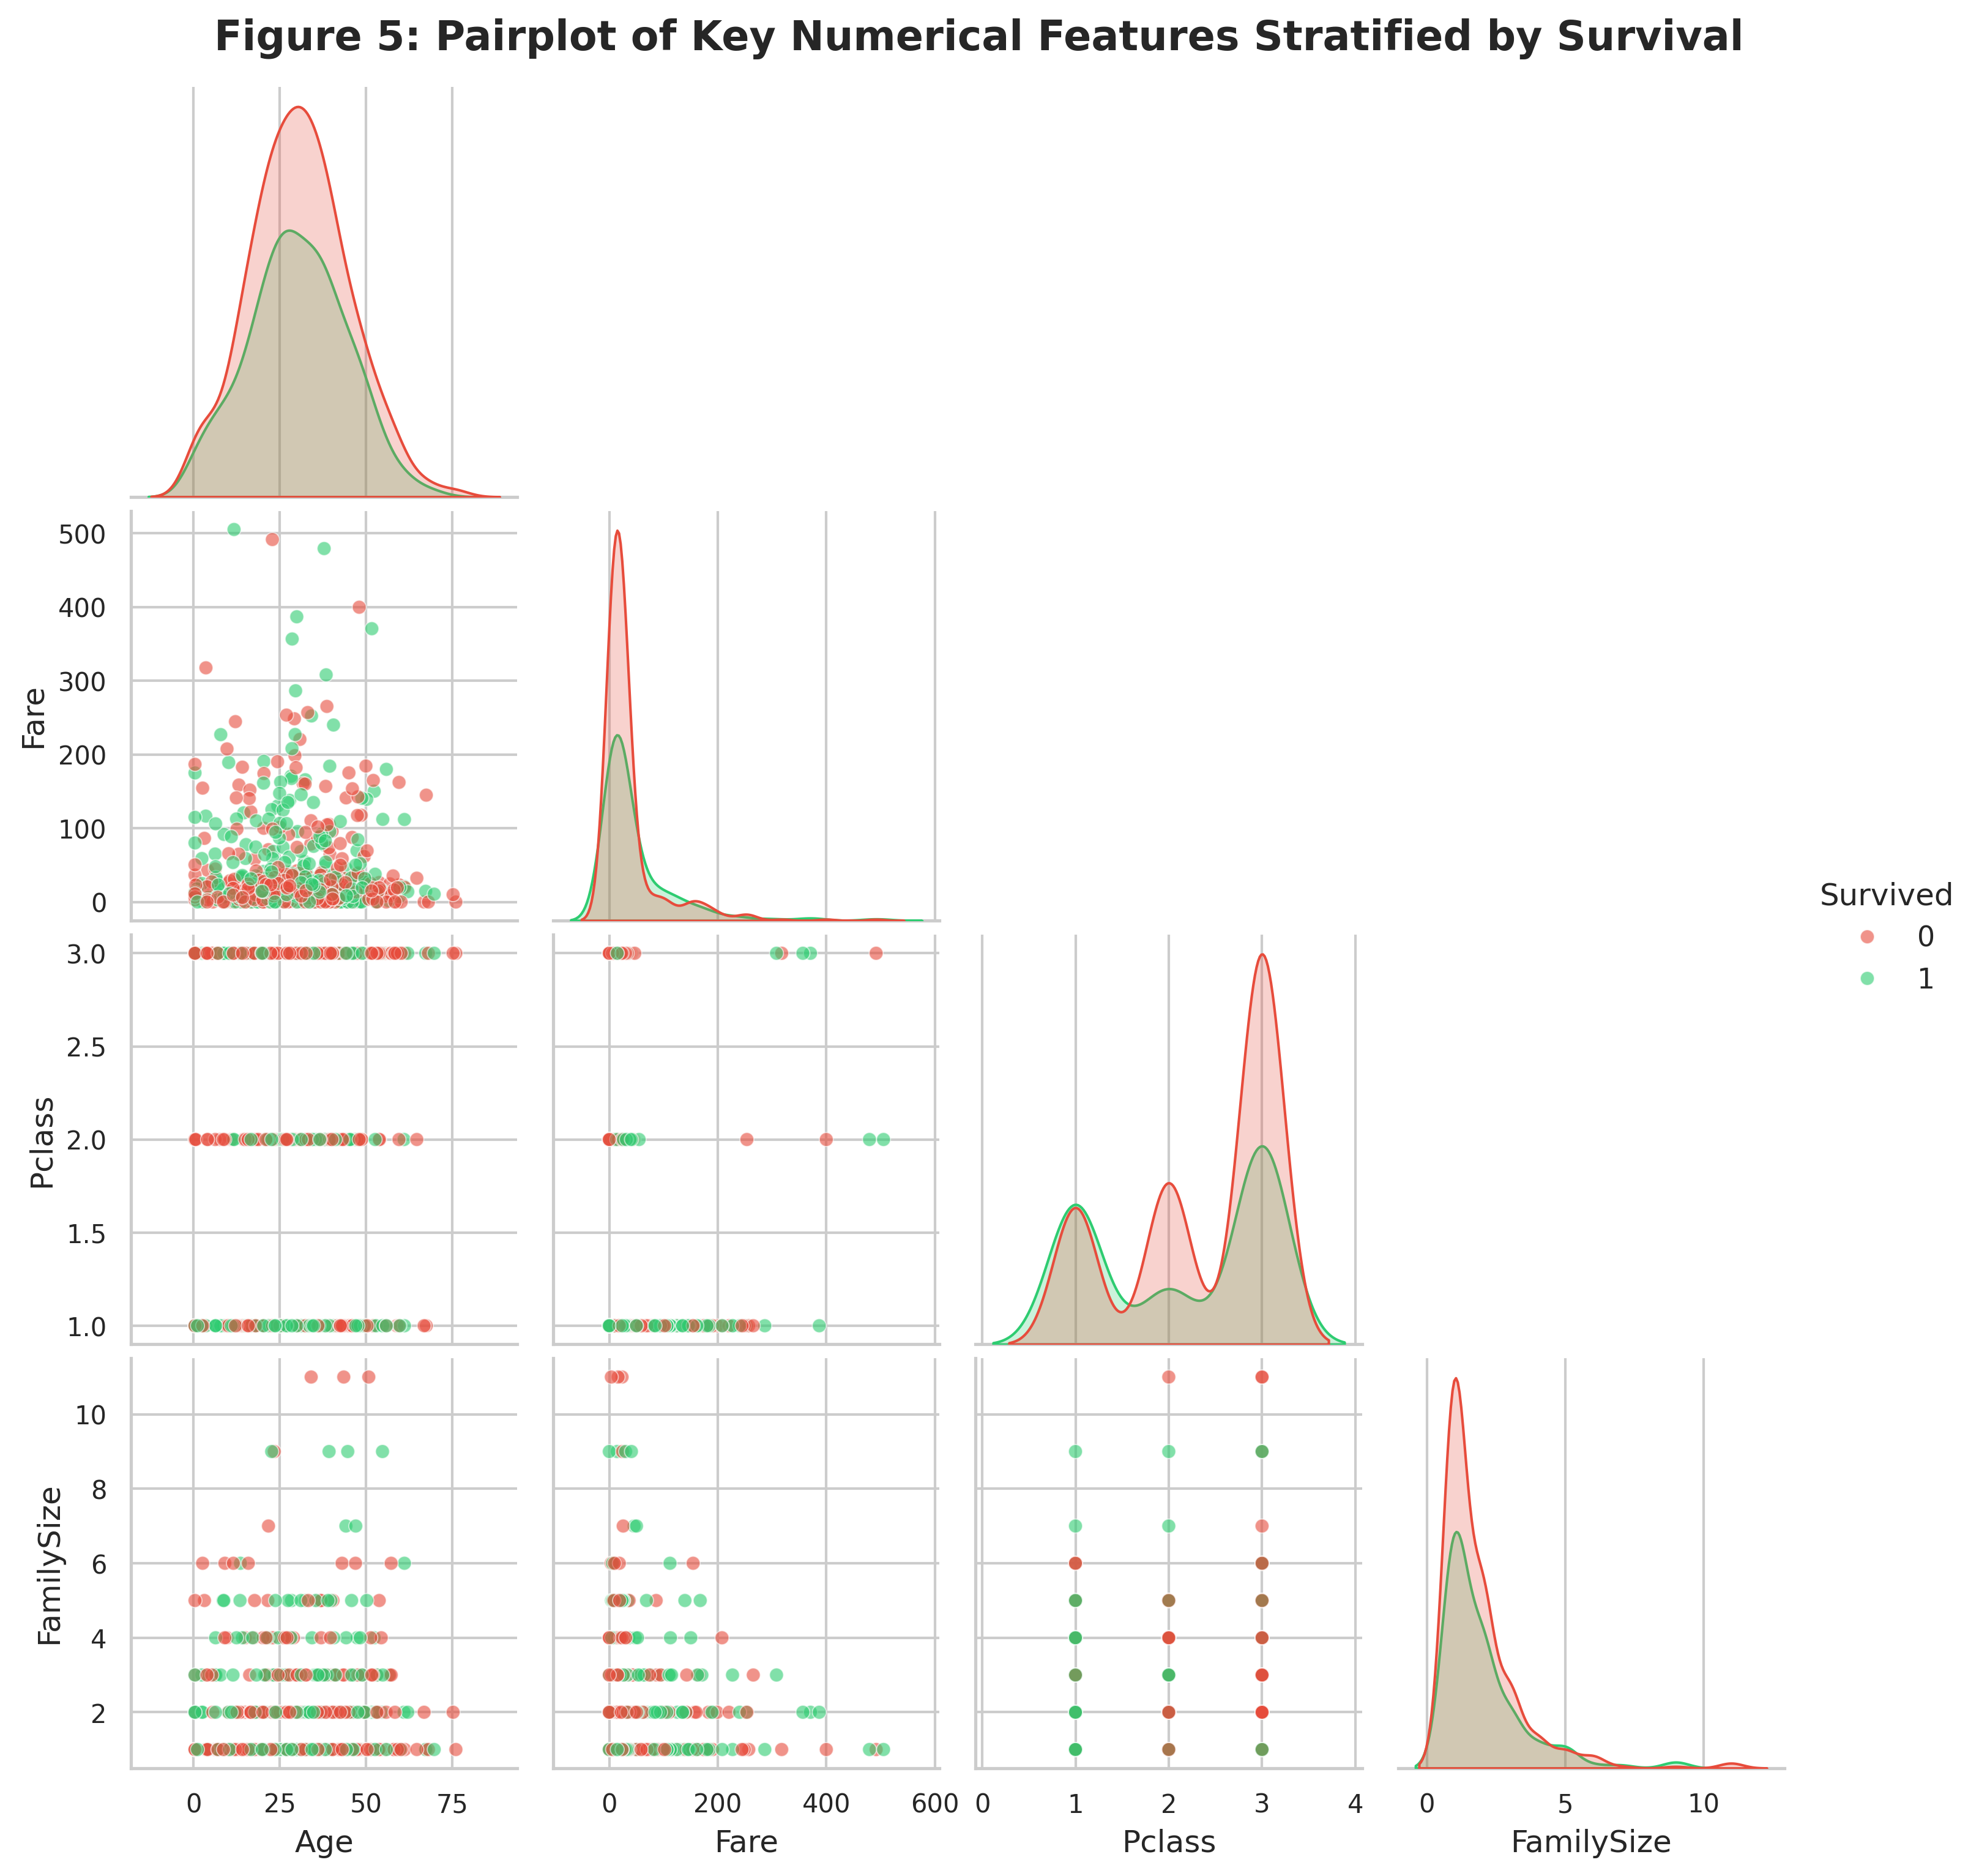

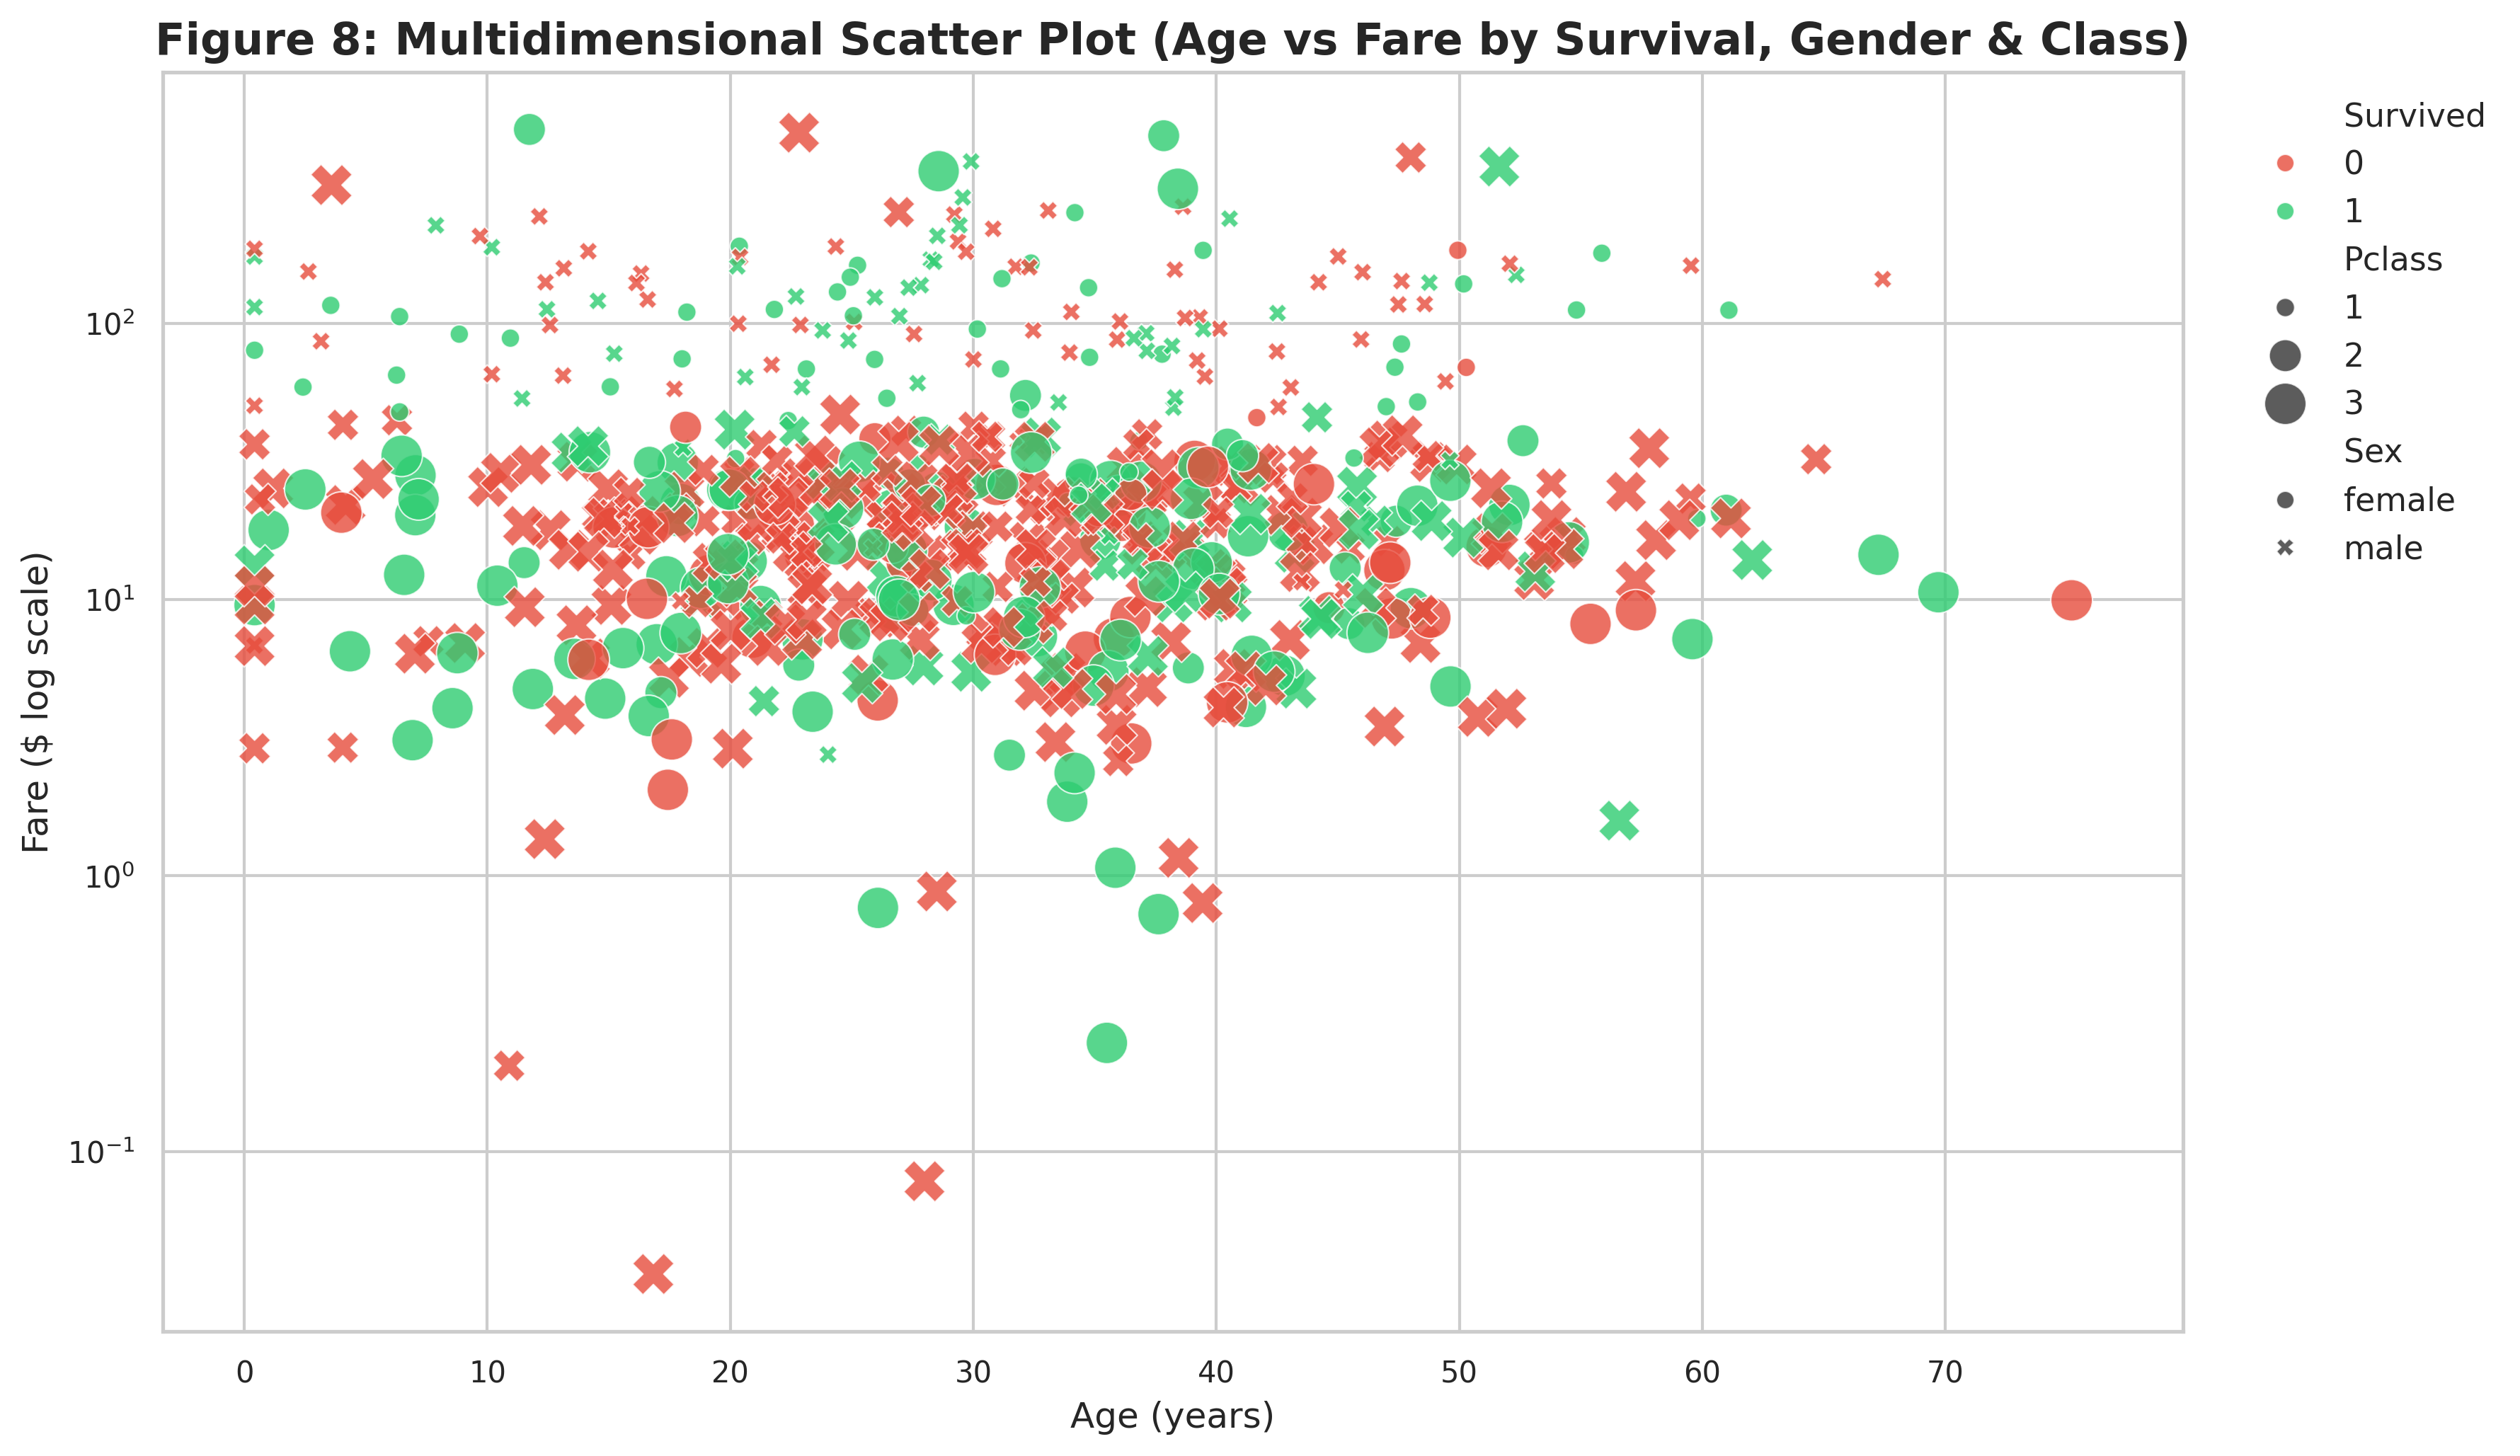

In [5]:
display(Image(filename="plots/04_correlation_heatmap.png"))
display(Image(filename="plots/05_pairplot.png"))
display(Image(filename="plots/08_age_fare_joint_distribution.png"))


## 5. Key EDA Inferences & Pattern Identification
1. **Gender Bias (Women & Children First)**: Female survival rate (~77.3%) was significantly higher than male survival rate (~21.8%).
2. **Socioeconomic Advantage**: First-class passengers enjoyed a ~57.2% survival rate, compared to 3rd class passengers at ~39.0%.
3. **Outliers & Fare Skewness**: Ticket Fare shows high positive skewness (skew = ~4.79) with heavy right-tail outliers reaching up to $512.
4. **Family Size Sweet Spot**: Passengers traveling in small families (2 to 4 members) achieved highest survival rates (~55-72%), whereas solo travelers (~30.4%) and large families (>4 members) faced severe survival penalties.
5. **Age & Class Interaction**: Children in 1st and 2nd class had the highest overall survival rates.
